In [1]:
import pymc
from magnus import NSFeas
import numpy as np
import matplotlib.pyplot as plt

In [2]:
R_GAS = 8.314 # J/K/mol
E_1 = 48_000 # J/mol
E_2 = 55_000 # J/mol

In [3]:
def theta_nominal():
    T_REF = 328.15
    k_1_ref = 8.84e-3 * 60 * 0.5 # 1/min
    k_2_ref = k_1_ref / 8
    theta_1 = k_1_ref * np.exp(E_1 / (R_GAS * T_REF))
    theta_2 = k_2_ref * np.exp(E_2 / (R_GAS * T_REF))

    return theta_1, theta_2

In [4]:
# initialize preexponentials
th_1, th_2 = theta_nominal()

# Feed concentrations
c_A_F, c_B_F, c_C_F = 11.28, 0, 0 # mol/L

def model(x):
    T_1, tau_1, T_2, tau_2 = x[0], x[1], x[2], x[3]

    # NOTE: rho (recycle ratio) is kept constant to keep a 4-dim design space
    # TODO: set rho -> 0 and verify consistency with no recycle setup
    rho = 0

    k_1_R1 = th_1 * np.exp(-E_1  / (R_GAS * T_1)) # Reaction 1 in CSTR-1
    k_1_R2 = th_1 * np.exp(-E_1  / (R_GAS * T_2)) # Reaction 1 in CSTR-2
    k_2_R1 = th_2 * np.exp(-E_2  / (R_GAS * T_1)) # Reaction 2 in CSTR-1
    k_2_R2 = th_2 * np.exp(-E_2  / (R_GAS * T_2)) # Reaction 2 in CSTR-2

    gamma = 1 + k_2_R2 * tau_2
    delta = 1 + k_1_R2 * tau_2

    c_A_R1_denom = rho - delta * (1 + k_1_R1 * tau_1)
    c_A_R1 = c_A_F * (rho - 1) * delta / c_A_R1_denom
    c_A_R2 = c_A_R1 / delta

    c_B_R1_num_1 = rho * k_1_R2 * c_A_R2 * tau_2
    c_B_R1_num_2 = gamma * (c_B_F * (1-rho) + k_1_R1 * c_A_R1 * tau_1)
    c_B_R1_denom = gamma * (1 + k_2_R1 * tau_1) - rho
    c_B_R1 = (c_B_R1_num_1 + c_B_R1_num_2) / c_B_R1_denom
    c_B_R2 = (c_B_R1 + k_1_R2 * c_A_R2 * tau_2) / gamma

    c_C_R1 = c_C_F - 1 / (rho - 1)  * (k_2_R1 * c_B_R1 * tau_1 + k_2_R2 * c_B_R2 * tau_2 * rho)
    c_C_R2 = c_C_R1 + k_2_R2 * c_B_R2 * tau_2

    return [c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2]

In [5]:
DAG = pymc.FFGraph()
DAG.options.MAXTHREAD = 1

T_1, tau_1 = DAG.add_var('T_1'), DAG.add_var('tau_1')
T_2, tau_2 = DAG.add_var('T_2'), DAG.add_var('tau_2')

op = pymc.FFCustom()
op.set_D_eval(model)
# applying the operation adds nodes to DAG
outs = op(ndep=6, var=[T_1, tau_1, T_2, tau_2], uid=0)
c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2 = outs[0], outs[1], outs[2], outs[3], outs[4], outs[5]
DAG


DAG VARIABLES:
  T_1	 => { Z0 Z1 Z2 Z3 Z4 Z5 }
  tau_1	 => { Z0 Z1 Z2 Z3 Z4 Z5 }
  T_2	 => { Z0 Z1 Z2 Z3 Z4 Z5 }
  tau_2	 => { Z0 Z1 Z2 Z3 Z4 Z5 }

DAG INTERMEDIATES:
  Z0	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[0]	 => { }
  Z1	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[1]	 => { }
  Z2	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[2]	 => { }
  Z3	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[3]	 => { }
  Z4	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[4]	 => { }
  Z5	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[5]	 => { }

In [6]:
# Setup nested sampler
NS = NSFeas()
NS.options.MAXTHREAD = 1           # Python callback + GIL: must be 1
NS.options.DISPLEVEL = 1           # console verbosity
NS.options.DISPITER  = 25          # rows per N iterations in table (cosemtic)
NS.options.NUMLIVE   = 500         # #Live Points
NS.options.NUMPROP   = 80           # Proposals per iteration
NS.options.MAXITER   = 0           # iterate until complete (hard iteration limit else)

NS.set_dag(DAG)
# contols for variables and bounds
NS.set_control([T_1, tau_1, T_2, tau_2], [298.15, 2, 298.15, 2], [353.15, 30, 353.15, 30])
NS.set_constraint([c_C_R1 / (c_A_R1 + c_B_R1 + c_C_R1) - 0.05,
                   0.55 - c_B_R2 / (c_A_R2 + c_B_R2 + c_C_R2), 
                   0.70 - (1 - c_A_R2 / c_A_F)])
NS.setup()
NS.sample()
NS.stats.display()


** INITIALIZING LIVE POINTS (500)      0.00 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.2212e-01    37        0     3.0000e-01
     25     5.2276e-02   177      811     2.1698e-01
     50     9.6986e-03   374     1166     1.8825e-01
     61    -3.0971e-04   505     1318     1.7715e-01

** EVALUATIONS:       5300 (0 FAILED)
** WALL TIME:         0.07 SEC


In [10]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "plots" / "tools"))
from trellis import trellis_plot

In [13]:
# NS.livepoints returns: (points[N, nu],  crit[N, 1],  prob[N, 1],  aux[N, 1])
live_pts, live_feas, *_ = NS.live_points
dead_pts, dead_feas, *_ = NS.dead_points

panel counts (rows = $\tau_2$ [min] high->low, cols = $T_2$ [K] low->high):
[[255 205  85]
 [264 251 110]
 [178 249 221]]
sum of panels = 1818   total points = 1818


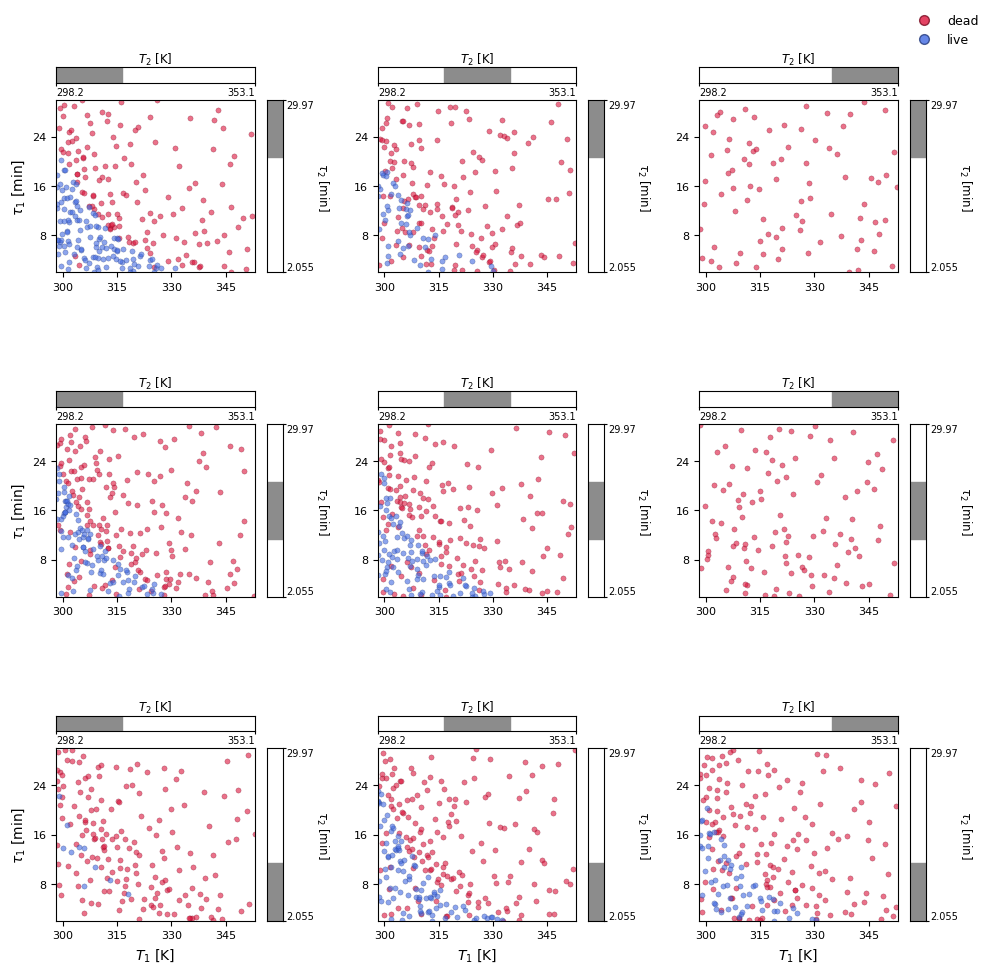

In [14]:
fig = trellis_plot(
     [dead_pts[:, 0], live_pts[:, 0]],   # T_1
    [dead_pts[:, 1], live_pts[:, 1]],   # tau_1
    [dead_pts[:, 2], live_pts[:, 2]],   # T_2
    [dead_pts[:, 3], live_pts[:, 3]],   # tau_2
    x_label=r"$T_1$ [K]", y_label=r"$\tau_1$ [min]",
    col_label=r"$T_2$ [K]", row_label=r"$\tau_2$ [min]",
    colors=["crimson", "royalblue"],
    labels=["dead", "live"],
)

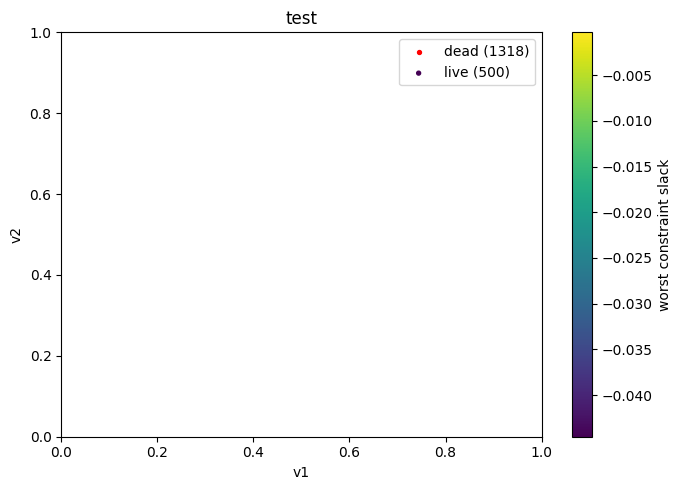

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
if dead_pts.size:
    v1_D, v2_D = dead_pts[:, 0], dead_pts[:, 1]
    ax.scatter(v1_D, v2_D, c='red', s=8, label=f'dead ({len(dead_pts)})')
if live_pts.size:
    v1_L, v2_L = live_pts[:, 0], live_pts[:, 1]
    sc = ax.scatter(v1_L, v2_L, c=live_feas[:, 0], cmap='viridis', s=8, label=f'live ({len(live_pts)})')
    fig.colorbar(sc, ax=ax, label='worst constraint slack')
ax.set(xlabel='v1', ylabel='v2',
       xlim=(0, 1), ylim=(0, 1),
       title='test')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()